In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio as rio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from collections import OrderedDict

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
# BAG-derived 30 m reference (earliest year meeting tau), from your Option 2 pipeline
BAG_YEAR_30M = Path("/mnt/intenso/masterarbeit/landsat/BAG_year_30m_tau050.tif")

# Directory containing CAY rasters (your examples like MAX_NDV_CAY.tif etc.)
CAY_DIR = Path("/mnt/intenso/masterarbeit/landsat/tsa_full/CAY")

# Glob for which CAT products to evaluate (CAY only here)
CAY_GLOB = "*_CAY.tif"

# Optional evaluation mask at 30 m (boolean/0-1); if None, evaluate everywhere
EVAL_MASK_30M = None  # e.g., Path("/path/to/change_mask_30m_frac_ge025.tif")

# Year bounds to keep
MIN_YEAR = 1982
MAX_YEAR = 2023

# Write residual rasters (predicted - truth) for visual QC?
WRITE_RESIDUALS = True
RESIDUALS_DIR = Path("/mnt/intenso/masterarbeit/landsat/residuals.tif")

# Write summary CSV?
SUMMARY_CSV = Path("/mnt/intenso/masterarbeit/landsat/cay_vs_bag_summary.csv")


In [3]:
def read_raster(path: Path):
    ds = rio.open(path)
    arr = ds.read(1)
    return ds, arr

def ensure_same_grid(ref_ds, src_ds, src_arr, allow_reproject=True):
    """Return src_arr aligned to ref_ds grid. If grids differ and allow_reproject=True, reproject."""
    same = (
        (ref_ds.crs == src_ds.crs) and
        (ref_ds.transform == src_ds.transform) and
        (ref_ds.width == src_ds.width) and
        (ref_ds.height == src_ds.height)
    )
    if same:
        return src_arr
    if not allow_reproject:
        raise ValueError("Grid differs and reproject not allowed.")
    dst = np.zeros((ref_ds.height, ref_ds.width), dtype=src_arr.dtype)
    reproject(
        source=src_arr,
        destination=dst,
        src_transform=src_ds.transform, src_crs=src_ds.crs,
        dst_transform=ref_ds.transform, dst_crs=ref_ds.crs,
        resampling=Resampling.nearest,
        src_nodata=0, dst_nodata=0
    )
    return dst

def valid_year_mask(arr, min_year=MIN_YEAR, max_year=MAX_YEAR):
    return (arr >= min_year) & (arr <= max_year)

def metrics_from_residuals(resid):
    resid = resid.astype(np.float64)
    mae = np.mean(np.abs(resid))
    medae = np.median(np.abs(resid))
    rmse = np.sqrt(np.mean(resid**2))
    bias = np.mean(resid)
    within1 = np.mean(np.abs(resid) <= 1.0) * 100.0
    within2 = np.mean(np.abs(resid) <= 2.0) * 100.0
    within5 = np.mean(np.abs(resid) <= 5.0) * 100.0
    return OrderedDict(
        n=resid.size,
        mae=mae,
        medae=medae,
        rmse=rmse,
        bias=bias,
        within_1y_pct=within1,
        within_2y_pct=within2,
        within_5y_pct=within5,
    )

def nice_name(path: Path):
    # Strip extension and directories, e.g. MAX_NDV_CAY
    return path.stem


In [4]:
# Load BAG 30 m reference raster
bag_ds, bag_year = read_raster(BAG_YEAR_30M)
print("BAG grid:", bag_ds.width, bag_ds.height, bag_ds.transform)

# Build a base mask: valid years in BAG
bag_valid = valid_year_mask(bag_year)

# Optional external evaluation mask
if EVAL_MASK_30M is not None:
    m_ds, m_arr = read_raster(EVAL_MASK_30M)
    m_arr = ensure_same_grid(bag_ds, m_ds, m_arr, allow_reproject=True)
    eval_mask = (m_arr > 0) & bag_valid
else:
    eval_mask = bag_valid

print(f"Eval pixels (so far): {eval_mask.sum():,}")


BAG grid: 3000 2000 | 30.00, 0.00, 85169.31|
| 0.00,-30.00, 512690.46|
| 0.00, 0.00, 1.00|
Eval pixels (so far): 71,028


In [5]:
cay_paths = sorted(CAY_DIR.glob(CAY_GLOB))
assert len(cay_paths) > 0, f"No CAY rasters found in {CAY_DIR} with pattern {CAY_GLOB}"
print("Found CAY rasters:")
for p in cay_paths:
    print(" -", p.name)

# Optional: verify all share CRS; they should if all EPSG:28992
for p in cay_paths:
    ds, _ = read_raster(p)
    if ds.crs != bag_ds.crs:
        raise ValueError(f"CRS mismatch for {p}: {ds.crs} vs {bag_ds.crs}")


Found CAY rasters:
 - MAX_NDB_CAY.tif
 - MAX_NDV_CAY.tif
 - MAX_NDW_CAY.tif
 - MAX_TCB_CAY.tif
 - MAX_TCW_CAY.tif
 - MIN_NDB_CAY.tif
 - MIN_NDV_CAY.tif
 - MIN_NDW_CAY.tif
 - MIN_TCB_CAY.tif
 - MIN_TCW_CAY.tif
 - Q90_NDB_CAY.tif
 - Q90_NDV_CAY.tif
 - Q90_NDW_CAY.tif
 - Q90_TCB_CAY.tif
 - Q90_TCW_CAY.tif


In [6]:
rows = []
if WRITE_RESIDUALS:
    RESIDUALS_DIR.mkdir(parents=True, exist_ok=True)

for p in cay_paths:
    name = nice_name(p)
    ds, pred = read_raster(p)
    pred = ensure_same_grid(bag_ds, ds, pred, allow_reproject=True)

    # Valid where both have meaningful years
    pred_valid = valid_year_mask(pred)
    mask = eval_mask & pred_valid

    n = int(mask.sum())
    if n == 0:
        print(f"{name}: no overlapping valid pixels; skipping.")
        continue

    resid = pred[mask].astype(np.int32) - bag_year[mask].astype(np.int32)
    m = metrics_from_residuals(resid)
    m = OrderedDict(name=name, **m)
    rows.append(m)

    print(f"{name}: n={n:,}  MAE={m['mae']:.2f}  MedAE={m['medae']:.2f}  RMSE={m['rmse']:.2f}  "
          f"Bias={m['bias']:.2f}  ±1y={m['within_1y_pct']:.1f}%  ±2y={m['within_2y_pct']:.1f}%  ±5y={m['within_5y_pct']:.1f}%")

    if WRITE_RESIDUALS:
        out_path = RESIDUALS_DIR / f"{name}__residual_vs_BAG.tif"
        meta = bag_ds.meta.copy()
        meta.update(count=1, dtype="int16", nodata=0)
        # Build a residual map with zeros where invalid
        full_resid = np.zeros_like(bag_year, dtype=np.int16)
        # Clip residuals to int16 range just in case
        rclip = np.clip((pred.astype(np.int32) - bag_year.astype(np.int32)), -32768, 32767).astype(np.int16)
        full_resid = np.where(mask, rclip, 0).astype(np.int16)
        with rio.open(out_path, "w", **meta) as dst:
            dst.write(full_resid, 1)

# Summary DataFrame
summary = pd.DataFrame(rows).sort_values(["mae", "rmse", "medae"])
display(summary)

if SUMMARY_CSV is not None:
    SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
    summary.to_csv(SUMMARY_CSV, index=False)
    print("Wrote summary CSV:", SUMMARY_CSV)


MAX_NDB_CAY: n=577  MAE=13.31  MedAE=11.00  RMSE=16.44  Bias=-1.32  ±1y=6.9%  ±2y=10.9%  ±5y=26.5%
MAX_NDV_CAY: n=486  MAE=14.28  MedAE=13.00  RMSE=17.57  Bias=2.63  ±1y=6.4%  ±2y=10.7%  ±5y=25.7%
MAX_NDW_CAY: n=891  MAE=13.90  MedAE=12.00  RMSE=16.92  Bias=1.01  ±1y=5.1%  ±2y=10.1%  ±5y=22.1%
MAX_TCB_CAY: n=438  MAE=14.21  MedAE=13.00  RMSE=17.30  Bias=1.93  ±1y=7.3%  ±2y=10.3%  ±5y=23.3%
MAX_TCW_CAY: n=172  MAE=12.70  MedAE=11.00  RMSE=15.74  Bias=2.60  ±1y=8.1%  ±2y=12.2%  ±5y=29.1%
MIN_NDB_CAY: n=697  MAE=13.40  MedAE=12.00  RMSE=16.39  Bias=0.56  ±1y=7.3%  ±2y=11.9%  ±5y=23.4%
MIN_NDV_CAY: n=621  MAE=13.44  MedAE=12.00  RMSE=16.47  Bias=2.67  ±1y=8.2%  ±2y=12.1%  ±5y=24.2%
MIN_NDW_CAY: n=802  MAE=14.55  MedAE=13.00  RMSE=17.59  Bias=3.55  ±1y=6.4%  ±2y=10.5%  ±5y=22.4%
MIN_TCB_CAY: n=608  MAE=13.07  MedAE=12.00  RMSE=15.94  Bias=0.25  ±1y=10.0%  ±2y=14.5%  ±5y=25.3%
MIN_TCW_CAY: n=166  MAE=12.02  MedAE=10.00  RMSE=15.10  Bias=4.23  ±1y=12.0%  ±2y=16.9%  ±5y=32.5%
Q90_NDB_CAY: n=52

,name,n,mae,medae,rmse,bias,within_1y_pct,within_2y_pct,within_5y_pct
14,Q90_TCW_CAY,138,11.565217,10.0,14.284886,1.144928,8.695652,15.942029,29.710145
9,MIN_TCW_CAY,166,12.018072,10.0,15.097873,4.234940,12.048193,16.867470,32.530120
4,MAX_TCW_CAY,172,12.697674,11.0,15.737306,2.604651,8.139535,12.209302,29.069767
10,Q90_NDB_CAY,528,13.037879,12.0,15.982945,0.465909,7.386364,13.068182,27.272727
8,MIN_TCB_CAY,608,13.069079,12.0,15.944600,0.253289,10.032895,14.473684,25.328947
0,MAX_NDB_CAY,577,13.308492,11.0,16.440271,-1.315425,6.932409,10.918544,26.516464
5,MIN_NDB_CAY,697,13.395983,12.0,16.385641,0.560976,7.317073,11.908178,23.385940
6,MIN_NDV_CAY,621,13.441224,12.0,16.466674,2.674718,8.212560,12.077295,24.154589
12,Q90_NDW_CAY,903,13.662237,12.0,16.824381,1.199336,8.194906,13.399779,24.806202
11,Q90_NDV_CAY,449,13.837416,12.0,17.207434,2.077951,8.685969,14.922049,25.612472


Wrote summary CSV: /mnt/intenso/masterarbeit/landsat/cay_vs_bag_summary.csv


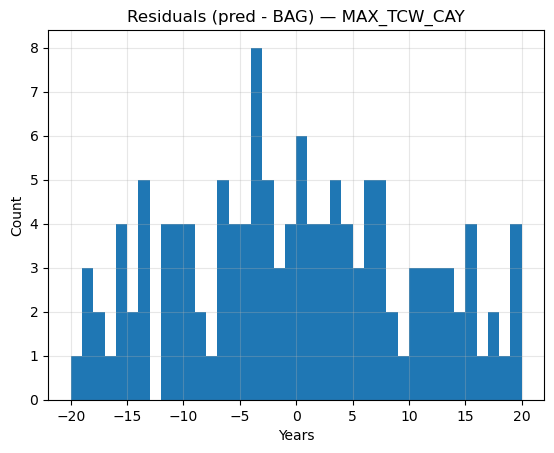

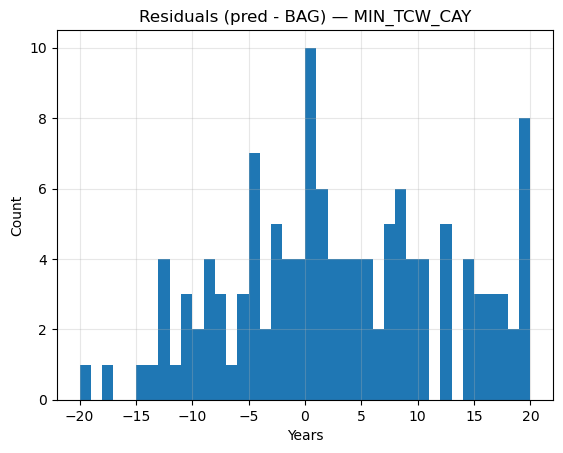

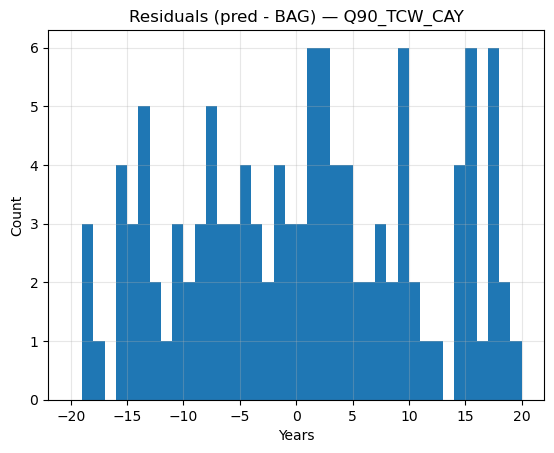

In [7]:
# Plot residual histograms for the top 3 performers by MAE
topk = summary.sort_values("mae").head(3)["name"].tolist()

bins = np.arange(-20, 21, 1)  # +/- 20 years window
for p in cay_paths:
    name = nice_name(p)
    if name not in topk:
        continue
    _, pred = read_raster(p)
    pred = ensure_same_grid(bag_ds, _, pred, allow_reproject=True)
    mask = eval_mask & valid_year_mask(pred)
    resid = pred[mask].astype(np.int32) - bag_year[mask].astype(np.int32)
    plt.figure()
    plt.hist(resid, bins=bins)
    plt.title(f"Residuals (pred - BAG) — {name}")
    plt.xlabel("Years"); plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()


In [8]:
# Build a boolean map showing where each product is within ±2 years of BAG
TOL = 2
agree_maps = []

for p in cay_paths:
    name = nice_name(p)
    ds, pred = read_raster(p)
    pred = ensure_same_grid(bag_ds, ds, pred, allow_reproject=True)
    mask = eval_mask & valid_year_mask(pred)
    agree = np.zeros_like(bag_year, dtype=np.uint8)
    resid = (pred.astype(np.int32) - bag_year.astype(np.int32))
    agree = np.where(mask & (np.abs(resid) <= TOL), 1, 0).astype(np.uint8)
    agree_maps.append(agree)

# Sum of agreements across all products per pixel (confidence proxy)
agree_sum = np.sum(np.stack(agree_maps, axis=0), axis=0).astype(np.uint8)

# Optional: write out
AGREE_SUM_TIF = SUMMARY_CSV.with_name("agreement_within2y_count.tif")
meta = bag_ds.meta.copy()
meta.update(count=1, dtype="uint8", nodata=0)
with rio.open(AGREE_SUM_TIF, "w", **meta) as dst:
    dst.write(agree_sum, 1)

print("Wrote:", AGREE_SUM_TIF)


Wrote: /mnt/intenso/masterarbeit/landsat/agreement_within2y_count.tif
